In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [4]:
orig_df = pd.read_excel("Dry_Bean_Dataset_filtered.xlsx")
orig_df.head()

,Area,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,208.178117,173.888747,1.197191,0.549812,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,200.524796,182.734419,1.097356,0.411785,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,212.826130,175.931143,1.209713,0.562727,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,210.557999,182.516516,1.153638,0.498616,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,201.847882,190.279279,1.060798,0.333680,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
orig_df.shape

(13611, 14)

In [6]:
orig_df.dtypes

Area                 int64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

In [7]:
for column in orig_df.columns:
    print(column, orig_df[column].unique())

Area [28395 28734 29380 ... 42139 42147 42159]
MajorAxisLength [208.17811671 200.52479566 212.82612986 ... 281.53992791 283.38263638
 295.14274099]
MinorAxisLength [173.88874704 182.73441935 175.93114261 ... 191.1879789  190.27573077
 182.2047159 ]
AspectRation [1.19719142 1.09735646 1.20971266 ... 1.47258175 1.48932623 1.61984139]
Eccentricity [0.54981219 0.41178525 0.56272732 ... 0.73406478 0.74105479 0.78669302]
Extent [0.76392252 0.78396813 0.77811325 ... 0.72993244 0.70538912 0.7889625 ]
Solidity [0.988856   0.9849856  0.98955877 ... 0.98989875 0.9878126  0.98964789]
roundness [0.95802713 0.88703364 0.94784947 ... 0.91842409 0.90790646 0.88838037]
Compactness [0.91335775 0.95386084 0.90877424 ... 0.8227297  0.81745745 0.78499719]
ShapeFactor1 [0.00733151 0.00697866 0.00724391 ... 0.00668122 0.00672367 0.00700071]
ShapeFactor2 [0.00314729 0.00356362 0.00304773 ... 0.00188827 0.00185203 0.00163981]
ShapeFactor3 [0.83422239 0.90985051 0.82587062 ... 0.67688416 0.66823668 0.61622059]


In [8]:
dummy_df = orig_df.drop(['Class'], axis=1)
output_var = 'Area'
input_vars = dummy_df.columns.tolist()
input_vars.remove(output_var)

df = dummy_df.dropna()
X = df[input_vars]
y = df[output_var]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1096.6825214546298), 0.9986381915107141]

# Filter Methods

## Missing Value Ratio

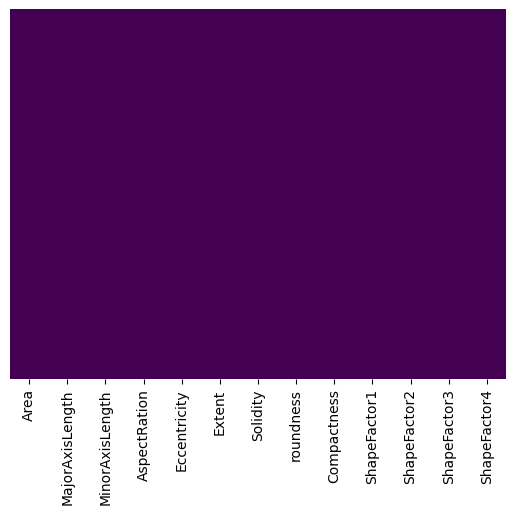

In [9]:
# Use heatmap to visualize missing value (null) positions
df=dummy_df.copy()
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

In [10]:
# Find missing value percent for each variable
null_percent = df.isnull().sum()/len(df)*100
null_percent

Area               0.0
MajorAxisLength    0.0
MinorAxisLength    0.0
AspectRation       0.0
Eccentricity       0.0
Extent             0.0
Solidity           0.0
roundness          0.0
Compactness        0.0
ShapeFactor1       0.0
ShapeFactor2       0.0
ShapeFactor3       0.0
ShapeFactor4       0.0
dtype: float64

## Low Variance Filtering

In [11]:
# Compute variance of each feature
df = dummy_df.copy()
df.var().sort_values(ascending=False)

Area               8.599026e+08
MajorAxisLength    7.343494e+03
MinorAxisLength    2.022309e+03
AspectRation       6.085026e-02
ShapeFactor3       9.800238e-03
Eccentricity       8.464324e-03
Compactness        3.808552e-03
roundness          3.542617e-03
Extent             2.409471e-03
Solidity           2.171913e-05
ShapeFactor4       1.906595e-05
ShapeFactor1       1.272380e-06
ShapeFactor2       3.550668e-07
dtype: float64

In [12]:
len(df.columns)

13

In [13]:
# After scanning variances from all features above, set minimum variance threshold = 1e-06
# Note that minimum variance threshold can be set to any value

# Below is to remove features with low variances
# Note that input_vars = a list of 12 original features
# Here, updated_vars = a list of features with variance >= minimum variance threshold

min_var_threshold = 1e-06
updated_vars = [ ]
for i in range(0,len(df[input_vars].var())):

    if df[input_vars].var().iloc[i] >= min_var_threshold:   
        updated_vars.append(df[input_vars].columns[i])
updated_vars

['MajorAxisLength',
 'MinorAxisLength',
 'AspectRation',
 'Eccentricity',
 'Extent',
 'Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor3',
 'ShapeFactor4']

In [14]:
len(updated_vars)

11

In [15]:
df2 = df[updated_vars]
df2['Area']=df.Area
df2.head()

/tmp/ipykernel_64228/4061967468.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Area']=df.Area


,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor3,ShapeFactor4,Area
0,208.178117,173.888747,1.197191,0.549812,0.763923,0.988856,0.958027,0.913358,0.007332,0.834222,0.998724,28395
1,200.524796,182.734419,1.097356,0.411785,0.783968,0.984986,0.887034,0.953861,0.006979,0.909851,0.998430,28734
2,212.826130,175.931143,1.209713,0.562727,0.778113,0.989559,0.947849,0.908774,0.007244,0.825871,0.999066,29380
3,210.557999,182.516516,1.153638,0.498616,0.782681,0.976696,0.903936,0.928329,0.007017,0.861794,0.994199,30008
4,201.847882,190.279279,1.060798,0.333680,0.773098,0.990893,0.984877,0.970516,0.006697,0.941900,0.999166,30140


In [16]:
df2 = df2.dropna()
X = df2[updated_vars]
y = df2['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1125.8421149723722), 0.9985648107443919]

## High Correlation Filtering

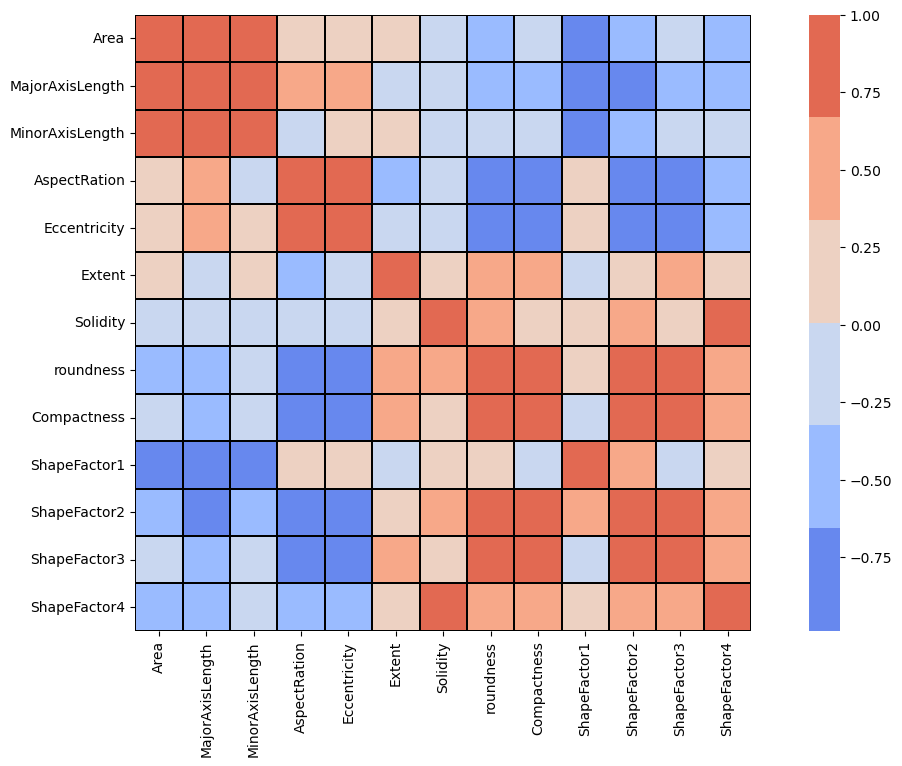

In [17]:
# Plot correlation of numerical data
df = dummy_df.copy()
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=False)
plt.show()

In [18]:
df = df.dropna()
X = df[input_vars]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1096.6825214546298), 0.9986381915107141]

In [19]:
df.shape

(13611, 13)

In [20]:
df[input_vars].corr()

,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
MajorAxisLength,1.000000,0.826052,0.550335,0.541972,-0.078062,-0.284302,-0.596358,-0.568377,-0.773609,-0.859238,-0.568185,-0.482527
MinorAxisLength,0.826052,1.000000,-0.009161,0.019574,0.145957,-0.155831,-0.210344,-0.015066,-0.947204,-0.471347,-0.019326,-0.263749
AspectRation,0.550335,-0.009161,1.000000,0.924293,-0.370184,-0.267754,-0.766979,-0.987687,0.024593,-0.837841,-0.978592,-0.449264
Eccentricity,0.541972,0.019574,0.924293,1.000000,-0.319362,-0.297592,-0.722272,-0.970313,0.019920,-0.860141,-0.981058,-0.449354
Extent,-0.078062,0.145957,-0.370184,-0.319362,1.000000,0.191389,0.344411,0.354212,-0.141616,0.237956,0.347624,0.148502
Solidity,-0.284302,-0.155831,-0.267754,-0.297592,0.191389,1.000000,0.607150,0.303766,0.153388,0.343559,0.307662,0.702163
roundness,-0.596358,-0.210344,-0.766979,-0.722272,0.344411,0.607150,1.000000,0.768086,0.230273,0.782824,0.763126,0.472149
Compactness,-0.568377,-0.015066,-0.987687,-0.970313,0.354212,0.303766,0.768086,1.000000,-0.009394,0.868939,0.998686,0.484436
ShapeFactor1,-0.773609,-0.947204,0.024593,0.019920,-0.141616,0.153388,0.230273,-0.009394,1.000000,0.469197,-0.008320,0.248619
ShapeFactor2,-0.859238,-0.471347,-0.837841,-0.860141,0.237956,0.343559,0.782824,0.868939,0.469197,1.000000,0.872971,0.529932


In [21]:
# Look at correlation matrix, 
# using 0.9 as a highly correlated

highly_corr = ['Eccentricity', 'Compactness']
df.drop(highly_corr, axis=1, inplace=True)
df.shape

(13611, 11)

In [22]:
## Perform regresssion with 8 original independent variables
## with dropping one of 5 features with high collinearity
output_vars = 'Area'
updated_vars = df.columns.tolist()
updated_vars.remove(output_vars)

df = df.dropna()
X = df[updated_vars]
y = df[output_vars]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1098.5793677716047), 0.9986334766086418]

In [23]:
# let's try further

df=dummy_df.copy()
df=df.drop('Eccentricity', axis=1)
df.shape

(13611, 12)

In [24]:
updated_vars = list(input_vars)
updated_vars.remove('Eccentricity')
print(len(updated_vars))
updated_vars

11


['MajorAxisLength',
 'MinorAxisLength',
 'AspectRation',
 'Extent',
 'Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3',
 'ShapeFactor4']

In [25]:
df = df.dropna()
X = df[updated_vars]
y = df.Area
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1096.5935135743844), 0.9986384125532961]

# Wrapper Methods

## Forward Feature Selection

In [26]:
df = dummy_df.copy()
df = df.dropna()

In [27]:
# f_regression receives input features and output
#              and returns f-statistic and p-value for f-test 
# f-test is to used to test whether model fits data well or not 
# the more f-statistic (the lower p-value), the better

from sklearn.feature_selection import f_regression
fstat, pval = f_regression(df[input_vars], df.Area)
fstat

array([8.97352000e+04, 1.30471111e+05, 8.44606800e+02, 1.04870425e+03,
       4.03113620e+01, 5.47068052e+02, 1.99457259e+03, 1.05365585e+03,
       3.48273493e+04, 9.40610402e+03, 1.08854133e+03, 1.97152431e+03])

In [28]:
pval

array([0.00000000e+000, 0.00000000e+000, 3.26094783e-180, 1.07646059e-221,
       2.23421278e-010, 1.18017781e-118, 0.00000000e+000, 1.07874943e-222,
       0.00000000e+000, 0.00000000e+000, 1.00878940e-229, 0.00000000e+000])

In [29]:
# Set threshold to select subset of features based on f-test statistic

# Note that input_vars = a list of 12 original features
# Here, updated_vars = a list of features selected from f-test statistic from forward feature selection

f_value_threshold = 10  # can adjust this value 
updated_vars = []
for i in range(0,len(input_vars)-1):
    if fstat[i] >= f_value_threshold:
        updated_vars.append(df[input_vars].columns[i])
updated_vars

['MajorAxisLength',
 'MinorAxisLength',
 'AspectRation',
 'Eccentricity',
 'Extent',
 'Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3']

In [30]:
## Perform regresssion with 12 features selected from f-test statistic from forward feature selection

X = df[updated_vars]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1099.450162558638), 0.9986313093859629]

In [31]:
### newly-added codebox for wrapper method

# The above codebox using f_regression tests how strongly and indepedently each feature is related to the output variable.
# But it does not directly help find the subset (or the combination) of multiple variables that result to the best model.
# This codebox will help find out the subset of variables that work best.

from sklearn.feature_selection import SequentialFeatureSelector

df = dummy_df.copy()
df = df.dropna()
X = df[input_vars]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
model = LinearRegression()
model.fit(X_train, y_train)

# Forward feature selection
sfs = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=5,
    direction="forward",      # forward elimination or backward
    scoring="neg_mean_squared_error", # neg_mean_squared_error or r2 for regression, acccuracy for classification
    cv=5,
    n_jobs=1
)

sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()]
print("Selected features:")
print(selected_features)

Selected features:
Index(['MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Compactness',
       'ShapeFactor1'],
      dtype='object')


In [32]:
X = df[selected_features]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
model_wrapper = LinearRegression()
model_wrapper.fit(X_train, y_train)
y_pred = model_wrapper.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1221.6569633228546), 0.9983101321522825]

## Recursive Feature Elimination

In [33]:
df = dummy_df.copy()
df = df.dropna()

In [34]:
# RFE receives fit model and number of features to select (which can be adjusted)
# rfe receives input features and output 

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

X = df[input_vars]
y = df['Area']
n_features = 10  # define by yourself to select important features

rfe = RFE(LinearRegression(), n_features_to_select=n_features)
model = rfe.fit(X, y)

In [35]:
# rfe masks features that are selected as 1
model.ranking_

array([2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [36]:
# to obtain coefficients of features in regression model
model.estimator_.coef_

array([ 1.03511413e+06, -6.42433767e+05,  8.41627244e+03, -3.26797040e+05,
        8.80370550e+04,  2.03866064e+07, -3.20391857e+07,  3.45319648e+07,
       -1.10234121e+07, -1.52675871e+06])

In [37]:
# Note that input_vars = a list of 12 original features
# Here, updated_vars = a list of features selected from recursive feature elimination

updated_vars = []
for i in range(0,len(input_vars)-1):
    if model.ranking_[i] == 1:
        updated_vars.append(df[input_vars].columns[i])
updated_vars

['AspectRation',
 'Eccentricity',
 'Extent',
 'Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3']

In [38]:
## Perform regresssion with features selected from recursive feature elimination

X = df[updated_vars]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

# R2 using features selected from rfe is quite low
# With this data, about 27 features need to be selected to get R2 > 0.5

[np.float64(12930.850283330832), 0.81067482796865]

In [39]:
# If you don't need to know which features get selected from rfe, 
#     you can use result model to predict immediately

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

X = df[input_vars]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
n_features = 10  # define by yourself to select important features

rfe = RFE(LinearRegression(), n_features_to_select=n_features)
model = rfe.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([24272.0289913 , 44501.42262307, 78695.1832776 , ...,
       65290.37451197, 36250.25302208, 48926.2733977 ], shape=(4084,))

# Embedded Methods

## Regression & Lasso (L1)

In [40]:
df = dummy_df.copy()
df = df.dropna()
X = df[input_vars]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)

In [41]:
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1096.6825214546298), 0.9986381915107141]

In [42]:
from sklearn.linear_model import Lasso

## Perform regresssion with embedded lasso 
## set alpha (weight of penalty term) = 1

lasso = Lasso(alpha=1)
model = lasso.fit(X_train, y_train)
y_pred = model.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.774e+10, tolerance: 8.096e+08
  model = cd_fast.enet_coordinate_descent(


[np.float64(3221.085678805686), 0.9882521404090929]

In [43]:
## We can look at values of coefficients of regression model 

[model.coef_, model.intercept_]

[array([ 2.83228441e+02,  2.74693679e+02, -1.97714894e+04,  2.47685903e+04,
        -3.48432809e+03, -0.00000000e+00,  3.16621079e+04,  0.00000000e+00,
         3.83468679e+06,  0.00000000e+00,  2.08376414e+04,  5.25448324e+04]),
 np.float64(-196384.57531524575)]

In [44]:
##  Filter features that has non-zero coefficients and sort coefficient from min to max
##  Note that argsort returns indices of array after sort
##  At the end, coef array = non-zero coeffients, sorted from min to max
##              update_vars = names of features corresponding to coef array

index = np.argsort(model.coef_)
coef = [model.coef_[index[i]] for i in range(len(model.coef_))  if model.coef_[index[i]] != 0]
update_vars = [input_vars[index[i]] for i in range(len(model.coef_))  if model.coef_[index[i]] != 0]
coef

[np.float64(-19771.489384856064),
 np.float64(-3484.3280909608548),
 np.float64(274.69367879362653),
 np.float64(283.228440935144),
 np.float64(20837.641430917185),
 np.float64(24768.59033823192),
 np.float64(31662.10791898916),
 np.float64(52544.832427553454),
 np.float64(3834686.789891056)]

In [45]:
update_vars

['AspectRation',
 'Extent',
 'MinorAxisLength',
 'MajorAxisLength',
 'ShapeFactor3',
 'Eccentricity',
 'roundness',
 'ShapeFactor4',
 'ShapeFactor1']

In [46]:
## Find out how many features have left after performing lasso with alpha = 1

len(update_vars)

9

In [47]:
## Run another regression with lasso + alpha 
selected_alpha=0.5     # can be adjusted
lasso2 = Lasso(alpha=selected_alpha)
model2 = lasso2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred2)),metrics.r2_score(y_test,y_pred2)]

/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.443e+10, tolerance: 8.096e+08
  model = cd_fast.enet_coordinate_descent(


[np.float64(1910.8578930982292), 0.9958656144453596]

In [48]:
[model2.coef_, model2.intercept_]

[array([ 3.16381261e+02,  3.22284164e+02, -2.32982103e+04,  1.58394137e+04,
        -2.59916154e+03, -0.00000000e+00,  2.01717565e+04,  1.26479672e+04,
         8.10473931e+06,  0.00000000e+00,  1.76169252e+04,  9.22250405e+04]),
 np.float64(-270522.61269707175)]

In [49]:
##  Filter features that has non-zero coefficients and sort coefficient from min to max

index = np.argsort(model2.coef_)
coef2 = [model2.coef_[index[i]] for i in range(len(model2.coef_))  if model2.coef_[index[i]] != 0]
update_vars2 = [input_vars[index[i]] for i in range(len(model2.coef_))  if model2.coef_[index[i]] != 0]
coef2

[np.float64(-23298.210341742957),
 np.float64(-2599.161538844426),
 np.float64(316.38126135119194),
 np.float64(322.28416395327235),
 np.float64(12647.967227876763),
 np.float64(15839.41374892078),
 np.float64(17616.925152376047),
 np.float64(20171.756477295847),
 np.float64(92225.04049422298),
 np.float64(8104739.313597875)]

In [50]:
update_vars2

['AspectRation',
 'Extent',
 'MajorAxisLength',
 'MinorAxisLength',
 'Compactness',
 'Eccentricity',
 'ShapeFactor3',
 'roundness',
 'ShapeFactor4',
 'ShapeFactor1']

In [51]:
## Find out how many features have left after performing lasso with alpha 
len(update_vars2)

10

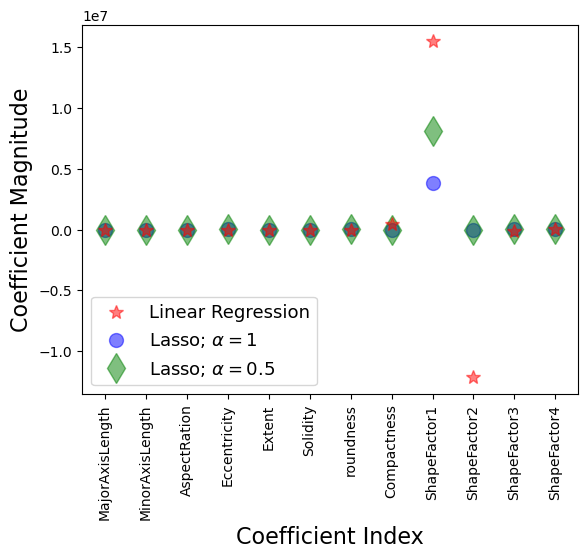

In [52]:
## Plot coefficients of linear regression model, regression with lasso + alpha=1,  regression with lasso + alpha=10
## Note that alpha parameter in plot indicates transparency of marker (it has nothing to do with alpha in lasso)

plt.plot(input_vars,lm.coef_,alpha=0.5,linestyle='none',marker='*',markersize=10,color='red',label=r'Linear Regression',zorder=7) # zorder for ordering the markers
plt.plot(input_vars,model.coef_,alpha=0.5,linestyle='none',marker='o',markersize=10,color='blue',label=r'Lasso; $\alpha = 1$') # alpha here is for transparency
plt.plot(input_vars,model2.coef_,alpha=0.5,linestyle='none',marker='d',markersize=15,color='green',label=r'Lasso; $\alpha = $'+str(selected_alpha)) # alpha here is for transparency
plt.xlabel('Coefficient Index',fontsize=16)
plt.ylabel('Coefficient Magnitude',fontsize=16)
plt.legend(fontsize=13,loc='lower left')
plt.xticks(input_vars, input_vars, rotation='vertical')
plt.show()

## Regression & Ridge (L2)

In [53]:
from sklearn.linear_model import Ridge

## Perform regresssion with ridge 
## set alpha (weight of penalty term) = 1

X = df[input_vars]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)

ridge = Ridge(alpha=1.0)
model = ridge.fit(X_train, y_train)
y_pred = model.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(4481.1752768643355), 0.9772627437725713]

In [54]:
[model.coef_, model.intercept_]

[array([   254.40453697,    230.1692881 , -16580.62870447,  27839.66299999,
         -4407.44770897,  -5850.23104989,  40295.75400436,   8569.78161127,
         13878.36600102,   3610.6966666 ,   8278.69227654,  15136.5669196 ]),
 np.float64(-123055.59643240002)]

In [55]:
##  Filter features that has non-zero coefficients and sort coefficient from min to max
##  Note that argsort returns indices of array after sort
##  At the end, coef array = non-zero coeffients, sorted from min to max
##              update_vars = names of features corresponding to coef array

index = np.argsort(model.coef_)
coef = [model.coef_[index[i]] for i in range(len(model.coef_))  if model.coef_[index[i]] != 0]
update_vars = [input_vars[index[i]] for i in range(len(model.coef_))  if model.coef_[index[i]] != 0]
coef

[np.float64(-16580.628704474166),
 np.float64(-5850.231049894937),
 np.float64(-4407.447708973845),
 np.float64(230.16928809981147),
 np.float64(254.40453697486697),
 np.float64(3610.6966666024614),
 np.float64(8278.692276541775),
 np.float64(8569.781611274575),
 np.float64(13878.366001021794),
 np.float64(15136.566919597974),
 np.float64(27839.662999992666),
 np.float64(40295.75400436234)]

In [56]:
update_vars

['AspectRation',
 'Solidity',
 'Extent',
 'MinorAxisLength',
 'MajorAxisLength',
 'ShapeFactor2',
 'ShapeFactor3',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor4',
 'Eccentricity',
 'roundness']

In [57]:
## Find out how many features have left after performing ridge with alpha = 1

len(update_vars)

12

In [58]:
## Run another regression with ridge + alpha
selected_alpha=0.1      # can be adjusted
ridge = Ridge(alpha=selected_alpha)
model2 = ridge.fit(X_train, y_train)
y_pred = model2.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(4382.777496360917), 0.9782503115910987]

In [59]:
[model2.coef_, model2.intercept_]

[array([   269.80704186,    213.15388292,  -3967.90620544,  62479.95128756,
         -4775.95557431, -87989.37890946,  47120.84439273,  46672.20004401,
        134392.32432189,  34758.84317173,  50939.42347419,  80157.74830742]),
 np.float64(-218601.06138116887)]

In [60]:
##  Filter features that has non-zero coefficients and sort coefficient from min to max

index = np.argsort(model2.coef_)
coef2 = [model2.coef_[index[i]] for i in range(len(model2.coef_))  if model2.coef_[index[i]] != 0]
update_vars2 = [input_vars[index[i]] for i in range(len(model2.coef_))  if model2.coef_[index[i]] != 0]
coef2

[np.float64(-87989.37890946055),
 np.float64(-4775.955574313528),
 np.float64(-3967.906205436498),
 np.float64(213.1538829167372),
 np.float64(269.80704186132164),
 np.float64(34758.84317173174),
 np.float64(46672.20004401491),
 np.float64(47120.844392732135),
 np.float64(50939.42347419355),
 np.float64(62479.95128755973),
 np.float64(80157.74830741774),
 np.float64(134392.32432189013)]

In [61]:
len(update_vars2)

12

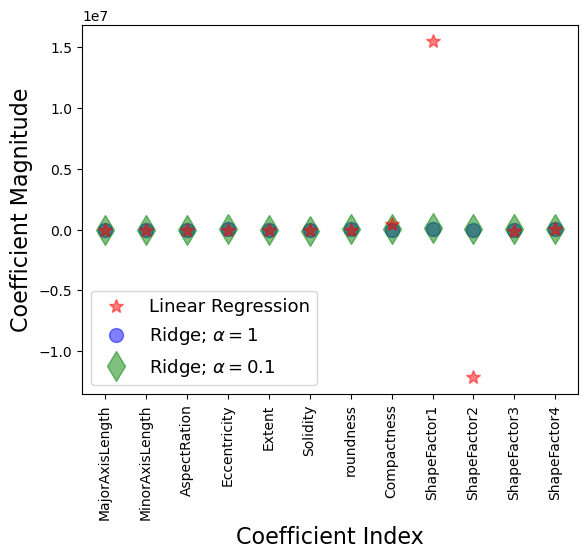

In [62]:
## Plot coefficients of linear regression model, regression with ridge + alpha=1,  regression with ridge + alpha=10
## Note that alpha parameter in plot indicates transparency of marker (it has nothing to do with alpha in ridge)

plt.plot(input_vars,lm.coef_,alpha=0.5,linestyle='none',marker='*',markersize=10,color='red',label=r'Linear Regression',zorder=7) # zorder for ordering the markers
plt.plot(input_vars,model.coef_,alpha=0.5,linestyle='none',marker='o',markersize=10,color='blue',label=r'Ridge; $\alpha = 1$') # alpha here is for transparency
plt.plot(input_vars,model2.coef_,alpha=0.5,linestyle='none',marker='d',markersize=15,color='green',label=r'Ridge; $\alpha = $'+str(selected_alpha)) # alpha here is for transparency
plt.xlabel('Coefficient Index',fontsize=16)
plt.ylabel('Coefficient Magnitude',fontsize=16)
plt.legend(fontsize=13,loc='lower left')
plt.xticks(input_vars, input_vars, rotation='vertical')
plt.show()

## Random Forest

In [63]:
df = dummy_df.copy()
df = df.dropna()

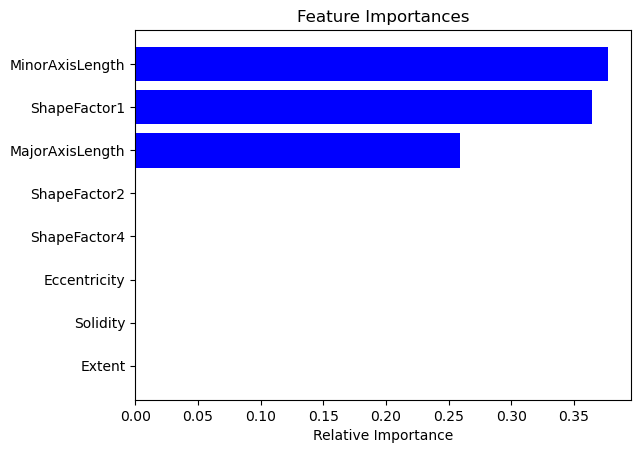

In [64]:
# RandomForestRegressor receives parameters for random forest such as depth of tree, number of trees

# n_features = number of selected features

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(max_depth=10,n_estimators=100)
model.fit(df[input_vars],df.Area)

n_features = 8      # can be adjusted

# Plot feature importance
features = df[input_vars].columns
importances = model.feature_importances_
indices = np.argsort(importances)[-n_features:]  # sort top n features
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# Choose features with large feature importance

In [65]:
# Note that input_vars = a list of original features
# Here, updated_vars = a list of features selected from feature importance of random forest
important_features = [features[i] for i in indices]
important_features
updated_vars = []
for i in range(-1,-n_features-1,-1):
    updated_vars.append(important_features[i])
updated_vars

['MinorAxisLength',
 'ShapeFactor1',
 'MajorAxisLength',
 'ShapeFactor2',
 'ShapeFactor4',
 'Eccentricity',
 'Solidity',
 'Extent']

In [66]:
## Perform regresssion with features selected from feature importance of random forest

X = df[updated_vars]
y = df['Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)
[np.sqrt(metrics.mean_squared_error(y_test,y_pred)),metrics.r2_score(y_test,y_pred)]

[np.float64(1278.3862453450872), 0.9981495456661574]

# LDA

In [67]:
cls_df = orig_df.copy()
df = cls_df.dropna()
y = df.Class
X = df.select_dtypes(include=['number'])

In [68]:
cls_df.Class.unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
selected_n_components = 6 # can be adjusted
lda = LinearDiscriminantAnalysis(n_components=selected_n_components)

X_lda = lda.fit_transform(X_scaled, y)

In [70]:
# How different variables contributes class separation
print("Discriminant coefficients (w):")
print(lda.scalings_)

Discriminant coefficients (w):
[[ 1.43578945e+00 -4.62270210e+00 -2.38679699e+00 -1.52916440e+01
   6.91174084e+00 -2.34570860e+01]
 [ 5.41223262e+00 -1.07995077e+01  6.25616061e+00  1.69964468e+01
  -7.41932503e+00  2.85215232e+01]
 [-1.36190806e+01  1.19112442e+01 -3.66184591e+00  4.28315777e+00
  -2.58531694e+00  1.09193730e+01]
 [-1.74315469e+00 -2.11241114e+00 -4.80120249e+01  1.35872544e+01
   1.16173827e+01 -2.18641982e+01]
 [ 8.67884007e-01  2.82043401e+00  1.51298915e+01 -1.05881042e+01
   2.20335917e+00  8.38334335e+00]
 [-5.03590231e-02  2.94670660e-02  2.08259269e-02  1.09500519e-01
  -5.51457579e-02  5.03224524e-02]
 [ 7.13699666e-02  1.94171221e-01 -4.83686908e-02 -2.12411208e-01
   1.16560124e-02 -1.66398667e-01]
 [ 3.61799769e-02 -4.63901505e-01 -3.56691501e-01 -6.09755820e-01
  -1.83658583e+00 -2.32280475e-01]
 [-6.83714317e+00 -4.44602210e+01 -2.61241002e+02  1.39040642e+02
   2.90973693e+01 -8.85653182e+01]
 [-7.14905824e-01 -5.71164090e+00  9.63547655e-01  3.6762492

In [71]:
# Interpret variable contribution to class separation
# Larger absolute value = stronger contribution to class separation
# Direction indicates which class side
# Compare coefficients within the same discriminant axis

scalings_df = pd.DataFrame(
    lda.scalings_,
    index=X.columns,
    columns=[f"LD{i+1}" for i in range(lda.scalings_.shape[1])]
)

scalings_df.abs().sort_values(by="LD1", ascending=False)

,LD1,LD2,LD3,LD4,LD5,LD6
ShapeFactor3,16.594215,27.499223,236.712108,130.253310,13.165473,83.991766
MinorAxisLength,13.619081,11.911244,3.661846,4.283158,2.585317,10.919373
ShapeFactor2,7.180197,9.689788,5.188774,0.506128,3.843442,1.395351
Compactness,6.837143,44.460221,261.241002,139.040642,29.097369,88.565318
MajorAxisLength,5.412233,10.799508,6.256161,16.996447,7.419325,28.521523
AspectRation,1.743155,2.112411,48.012025,13.587254,11.617383,21.864198
Area,1.435789,4.622702,2.386797,15.291644,6.911741,23.457086
Eccentricity,0.867884,2.820434,15.129892,10.588104,2.203359,8.383343
ShapeFactor1,0.714906,5.711641,0.963548,3.676249,0.150669,12.200757
ShapeFactor4,0.239913,0.140332,1.296258,0.195802,0.011484,0.898967


In [72]:
print(lda.explained_variance_ratio_)

[0.53863835 0.22196444 0.10350927 0.09377186 0.02676781 0.01534827]


In [73]:
# LDA scaling can be "roughly" used to rank variables by magnitude
# Note: To get exact and better ranking, perform feature selection instead.  
#       LDA is mainly used to find projection for best separation, not for feature importance.

feature_importance = scalings_df.abs().sum(axis=1)
feature_importance.sort_values(ascending=False)

Compactness        569.241696
ShapeFactor3       508.216094
AspectRation        98.936426
MajorAxisLength     75.405196
Area                54.105759
MinorAxisLength     46.980018
Eccentricity        39.993016
ShapeFactor2        27.803681
ShapeFactor1        23.417770
roundness            3.535395
ShapeFactor4         2.782755
Solidity             0.704376
Extent               0.315621
dtype: float64

In [74]:
# Classifier coefficients
# Magnitude of coefficients: Which  variable is important for which class
# Sign of coefficients: Direction of separation

coef_df = pd.DataFrame(
    lda.coef_,
    columns=X.columns,
    index=lda.classes_
)
coef_df

,Area,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
BARBUNYA,-54.632305,39.526462,48.340960,-4.014994,-7.029651,0.437759,-0.830143,-6.377658,107.795879,15.048212,11.530107,-118.903570,3.200570
BOMBAY,45.743881,-112.354969,179.867770,53.334435,-13.954354,0.434798,-1.421950,2.923018,190.789354,22.108476,88.803522,-291.278927,2.962094
CALI,-68.434253,20.212165,84.024204,-22.788078,-10.546070,0.551385,-0.259392,0.846672,-10.285411,1.891021,50.511468,-81.356606,1.564285
DERMASON,6.923406,33.858482,-42.274155,76.591078,-24.743278,-0.213249,-0.164390,1.519781,486.741153,13.885005,-25.002120,-388.022823,-2.276120
HOROZ,15.709991,-94.131448,45.079419,-39.617566,41.701060,-0.154850,1.477106,-1.807003,-549.966194,-36.057210,43.070030,455.319258,-1.125207
SEKER,21.377137,44.834130,-78.453835,-186.044956,59.595161,-0.226841,-0.246360,1.177277,-988.122792,11.924028,-58.616227,952.841835,4.110113
SIRA,23.415294,-21.246603,-27.594924,74.550700,-30.232134,-0.072041,0.188525,0.468054,421.829521,-14.569293,-7.396944,-376.133387,-2.434686


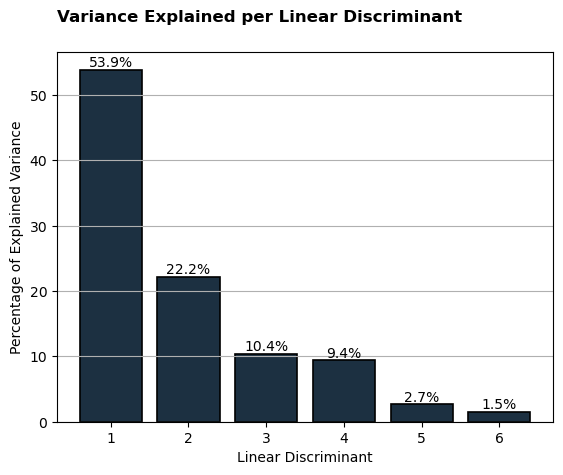

In [75]:
# LDA Explained Variance Plot
# LDA bar height = proportion of between-class variance explained
# Note: PCA bar height = total data variance != LDA bar height 

plot_y = [val * 100 for val in lda.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Linear Discriminant")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Linear Discriminant", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

# PCA

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

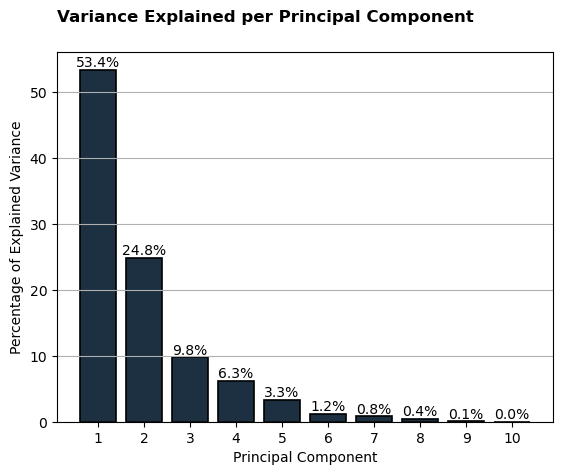

In [77]:
plot_y = [val * 100 for val in pca.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

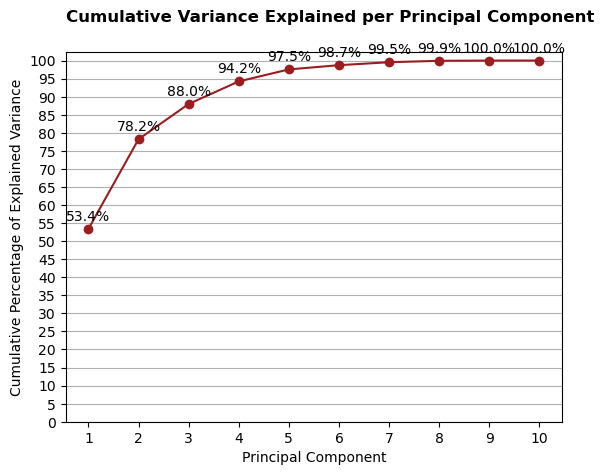

In [78]:
exp_var = [val * 100 for val in pca.explained_variance_ratio_]
plot_y = [sum(exp_var[:i+1]) for i in range(len(exp_var))]
plot_x = range(1, len(plot_y) + 1)

plt.plot(plot_x, plot_y, marker="o", color="#9B1D20")
for x, y in zip(plot_x, plot_y):
    plt.text(x, y + 1.5, f"{y:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Percentage of Explained Variance")
plt.title("Cumulative Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)

plt.yticks(range(0, 101, 5))
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

In [79]:
# To see contribution of each original variable on each PC
# Larger absolute value = stronger contribution to that PC
# Direction (+/-) shows correlation direction
# Meaningful within the same PC
# Do not use this to look at importance of variables

components_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
components_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Area,-0.235546,0.412689,0.100608,-0.060816,0.089844,0.479039,-0.304189,-0.120851,0.012808,-0.234659
MajorAxisLength,-0.320371,0.283489,0.119301,-0.034405,0.049509,0.089884,-0.194627,0.177122,0.387060,-0.034056
MinorAxisLength,-0.162353,0.498494,0.037277,-0.094237,0.011314,0.150762,-0.026271,-0.119477,-0.389638,0.355495
AspectRation,-0.329348,-0.235591,0.164325,0.052669,0.024590,-0.141456,-0.358713,0.523805,-0.118391,0.530963
Eccentricity,-0.328924,-0.221745,0.159635,0.117446,0.055234,0.290196,0.468165,-0.404368,0.323019,0.464995
Extent,0.118132,0.215744,0.112213,0.941374,-0.196267,-0.018584,-0.040142,0.014355,-0.005718,0.001496
Solidity,0.184150,0.010129,0.737276,-0.062893,0.296759,-0.375357,-0.229099,-0.369890,0.013375,-0.003084
roundness,0.321451,0.089157,0.158363,0.069964,0.651622,0.295549,0.357633,0.466226,-0.036917,0.008955
Compactness,0.338770,0.227665,-0.146066,-0.086102,-0.056913,-0.010330,0.040093,-0.166485,-0.041595,0.301611
ShapeFactor1,0.151473,-0.486993,-0.014801,0.108706,0.090722,0.525710,-0.388596,-0.218363,-0.368565,0.010867


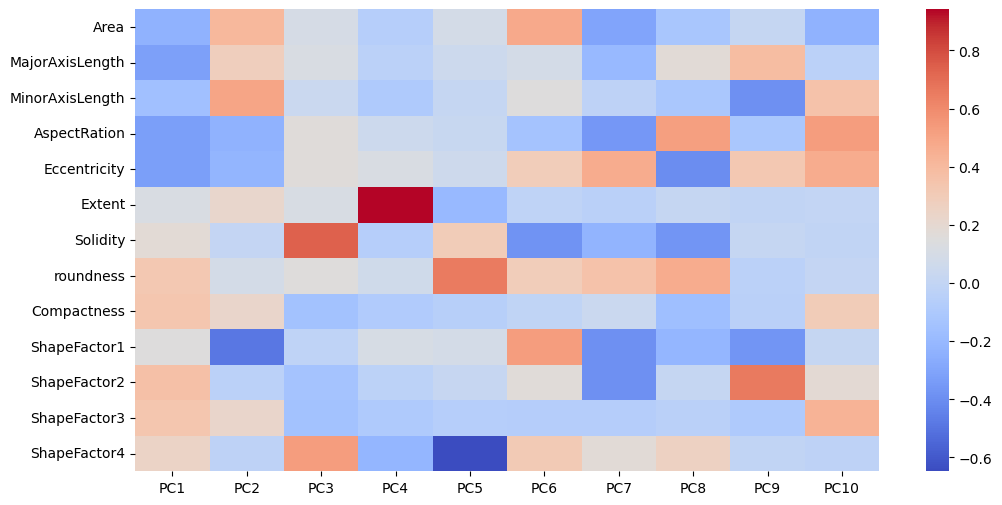

In [80]:
plt.figure(figsize=(12,6))
sns.heatmap(components_df,cmap='coolwarm')
plt.show()

# y axis = each variable
# The result shows that each variable contributes to each principal component

# Factor Analysis

In [81]:
fac_df = orig_df.select_dtypes(include=[np.number]).dropna().copy()

In [82]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

chi_square_value, p_value = calculate_bartlett_sphericity(fac_df)
kmo_all, kmo_model = calculate_kmo(fac_df)

print("Bartlett’s test p-value:", p_value)
print("KMO overall:", kmo_model)

# Bartlett p < 0.05 → correlations exist 
# KMO > 0.6 → FA is appropriate 

Bartlett’s test p-value: 0.0
KMO overall: 0.62096229980951


/home/tako/Kasetsart/statistics/.devenv/state/venv/lib/python3.13/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


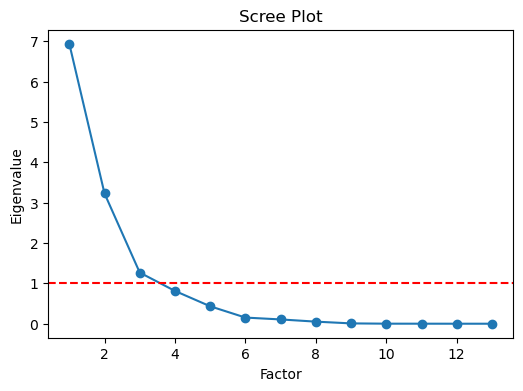

In [83]:
# Determine number of factors (Eigenvalues)
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

fa = FactorAnalyzer(rotation=None)
fa.fit(fac_df)

eigenvalues, _ = fa.get_eigenvalues()

# Scree plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.axhline(y=1, color='red', linestyle='--')
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

#Kaiser criterion → eigenvalue > 1
#Scree “elbow” → typical solution ≈ 3–5 factors

In [84]:
# Run Factor Analysis: Least Squares (default) (with rotation)
selected_n_factors = 5   # can be adjusted
fa = FactorAnalyzer(n_factors=selected_n_factors, method="minres", rotation='varimax')  # other options for method are 'principal' and 'ml'
fa.fit(fac_df)

factor_columns = []
for i in range(1,selected_n_factors+1):
    factor_columns.append("Factor"+str(i))

loadings = pd.DataFrame(
    fa.loadings_,
    index=fac_df.columns,
    columns=factor_columns
)

print(loadings.round(2))

                 Factor1  Factor2  Factor3  Factor4  Factor5
Area               -0.18     0.96    -0.10     0.03     0.18
MajorAxisLength    -0.48     0.86    -0.15    -0.02     0.03
MinorAxisLength     0.08     0.99    -0.09    -0.00     0.02
AspectRation       -0.97     0.06    -0.12    -0.08     0.01
Eccentricity       -0.95     0.08    -0.15    -0.01     0.03
Extent              0.34     0.13     0.11     0.18    -0.02
Solidity            0.14    -0.08     0.95     0.24    -0.02
roundness           0.68    -0.23     0.37     0.59     0.03
Compactness         0.98    -0.08     0.16     0.04    -0.02
ShapeFactor1       -0.10    -0.95     0.09     0.06     0.28
ShapeFactor2        0.82    -0.52     0.18     0.07     0.12
ShapeFactor3        0.98    -0.08     0.16     0.03    -0.02
ShapeFactor4        0.36    -0.23     0.70    -0.14     0.03


/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


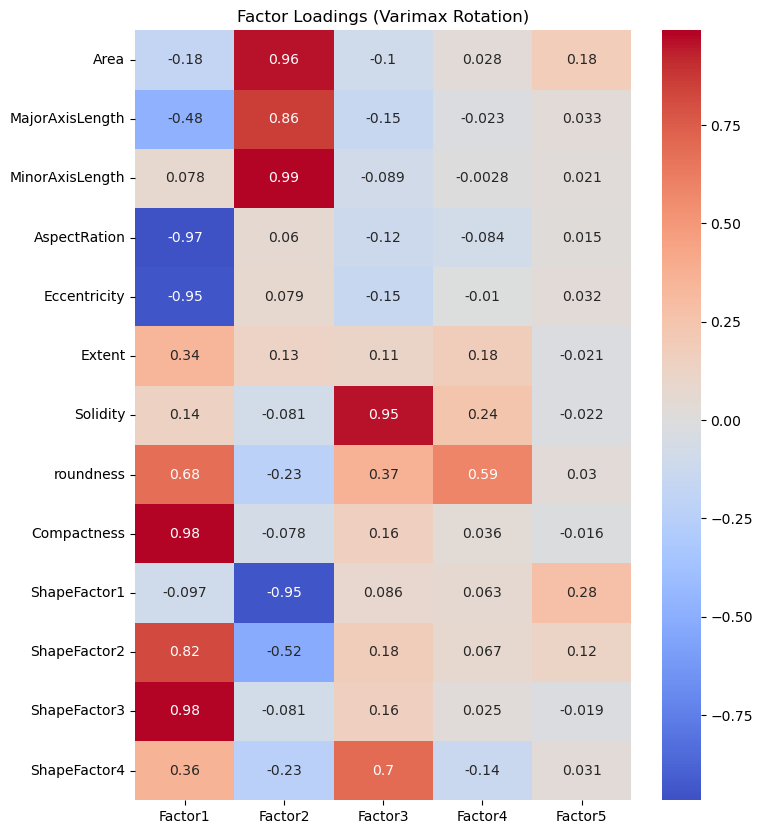

In [85]:
# Interpret factor loadings
plt.figure(figsize=(8,10))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("Factor Loadings (Varimax Rotation)")
plt.show()

# High loading (>|0.4|) → variable belongs to factor
# Factors represent latent abilities (e.g. verbal, spatial, memory)

In [86]:
# Communalities & variance explained
communalities = pd.Series(fa.get_communalities(), index=fac_df.columns)
variance = pd.DataFrame(
    fa.get_factor_variance(),
    index=["SS Loadings", "Proportion Var", "Cumulative Var"],
    columns=factor_columns
)

print("Communalities:")
print(communalities.round(2))

print("\nVariance explained:")
print(variance.round(3))

# Communality → how much variance of a variable is explained
# Cumulative variance → how much total variance factors explain

Communalities:
Area               1.00
MajorAxisLength    0.99
MinorAxisLength    1.00
AspectRation       0.96
Eccentricity       0.93
Extent             0.18
Solidity           1.00
roundness          1.00
Compactness        1.00
ShapeFactor1       1.00
ShapeFactor2       0.99
ShapeFactor3       1.00
ShapeFactor4       0.69
dtype: float64

Variance explained:
                Factor1  Factor2  Factor3  Factor4  Factor5
SS Loadings       5.454    3.965    1.712    0.472    0.132
Proportion Var    0.420    0.305    0.132    0.036    0.010
Cumulative Var    0.420    0.725    0.856    0.893    0.903


In [87]:
# Compute Factor Scores

# Get factor scores for each observation
factor_scores = fa.transform(fac_df)  # shape: (n_samples, n_factors)

factor_scores_df = pd.DataFrame(factor_scores, columns=factor_columns)
print(factor_scores_df)

        Factor1   Factor2   Factor3   Factor4   Factor5
0      1.626081 -0.702684 -0.711508  0.818708 -0.571856
1      2.181293 -0.471856 -0.843302 -0.473686  1.197575
2      1.502480 -0.656352 -0.378906  0.350967 -0.604361
3      2.985960 -0.566244 -2.747438 -0.340519  1.007047
4      2.857108  0.038703  0.758528  2.243304  3.360256
...         ...       ...       ...       ...       ...
13606 -0.160843 -0.302159  0.522994  1.001549 -0.419352
13607  0.462378 -0.145507  0.777255  0.332313 -0.330881
13608  0.599631 -0.127850  0.690745  0.168459 -0.157415
13609  0.635408 -0.171427  0.285155  0.104687  0.017406
13610 -0.672615 -0.429566  0.401339  0.770996 -0.416012

[13611 rows x 5 columns]


/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
